In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/cleaned_retail.csv")

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Year,Month,Day,Weekday
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,12,1,Tuesday
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,1,Tuesday
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,1,Tuesday
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009,12,1,Tuesday
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009,12,1,Tuesday


In [2]:
# top 20 products by quantity sold
product_demand = (
    df.groupby("Description")["Quantity"]
      .sum()
      .sort_values(ascending=False)
      .head(20)
)

product_demand

Description
WHITE HANGING HEART T-LIGHT HOLDER     56814
WORLD WAR 2 GLIDERS ASSTD DESIGNS      54610
BROCADE RING PURSE                     48166
PACK OF 72 RETRO SPOT CAKE CASES       45129
ASSORTED COLOUR BIRD ORNAMENT          44431
60 TEATIME FAIRY CAKE CASES            35656
PACK OF 60 PINK PAISLEY CAKE CASES     30871
JUMBO BAG RED RETROSPOT                29519
SMALL POPCORN HOLDER                   25703
BLACK AND WHITE PAISLEY FLOWER MUG     25685
STRAWBERRY CERAMIC TRINKET BOX         25330
PACK OF 12 SUKI TISSUES                24687
PACK OF 72 SKULL CAKE CASES            24455
COLOUR GLASS T-LIGHT HOLDER HANGING    23944
PACK OF 12 RED SPOTTY TISSUES          22641
ASSTD DESIGN BUBBLE GUM RING           22410
GIRLS ALPHABET IRON ON PATCHES         22177
PACK OF 12 PINK PAISLEY TISSUES        21979
ROTATING SILVER ANGELS T-LIGHT HLDR    21579
72 SWEETHEART FAIRY CAKE CASES         21183
Name: Quantity, dtype: int64

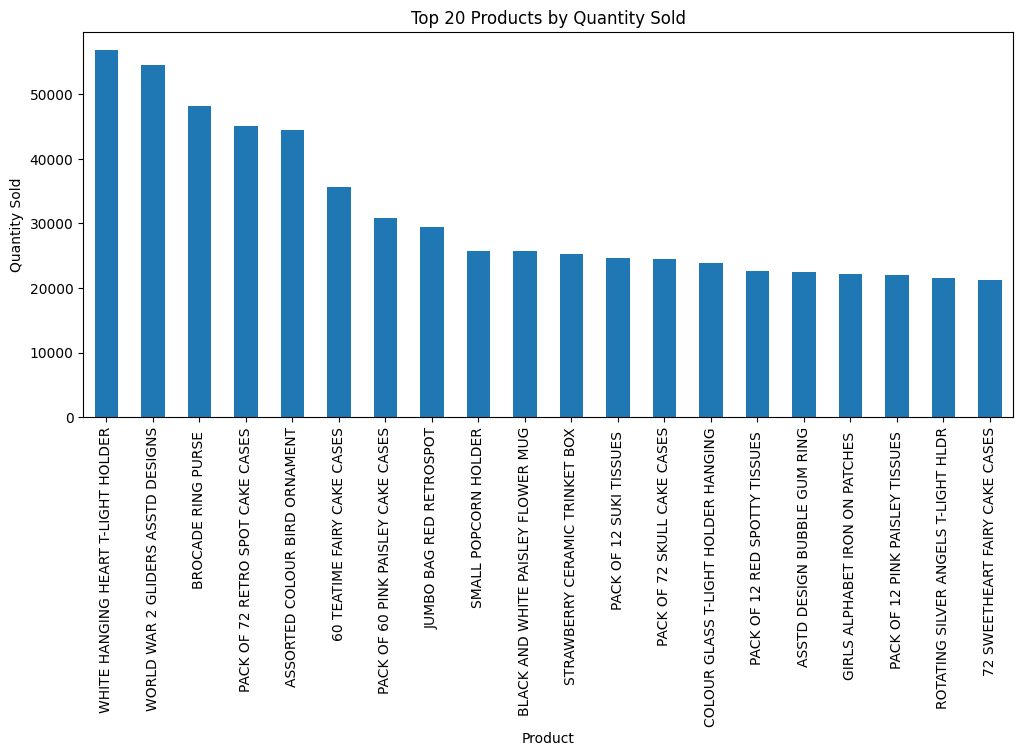

In [3]:
# visualization
plt.figure(figsize=(12,5))

product_demand.plot(kind="bar")

plt.title("Top 20 Products by Quantity Sold")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")

plt.show()

# Product Demand Insights

1. A small number of products contribute a large share of total demand.
2. High-demand products require continuous inventory monitoring.
3. Stock shortages in these products may significantly affect sales performance.
4. Demand concentration suggests prioritizing inventory for best-selling products.

In [4]:
# creating inventory dataset
inventory = (
    df.groupby("Description")
      .agg({
          "Quantity":"sum",
          "Revenue":"sum"
      })
      .reset_index()
)

inventory.head()

,Description,Quantity,Revenue
0,DOORMAT UNION JACK GUNS AND ROSES,167,1071.25
1,3 STRIPEY MICE FELTCRAFT,662,1241.10
2,4 PURPLE FLOCK DINNER CANDLES,200,265.20
3,ANIMAL STICKERS,385,80.85
4,BLACK PIRATE TREASURE CHEST,45,74.25


In [5]:
# inventory risk classification
high_demand_threshold = inventory["Quantity"].quantile(0.75)

print(high_demand_threshold)

1112.75


In [6]:
# creating risk categories
inventory["Risk"] = np.where(
    inventory["Quantity"] > high_demand_threshold,
    "High Demand",
    "Normal Demand"
)

In [7]:
inventory["Risk"].value_counts()

Risk
Normal Demand    3333
High Demand      1111
Name: count, dtype: int64

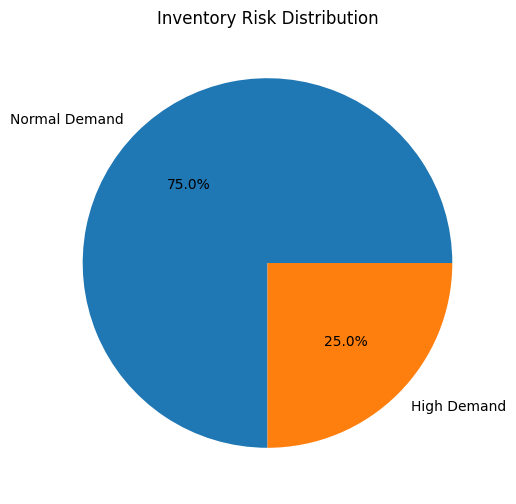

In [8]:
# Risk distribution chart
inventory["Risk"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.title("Inventory Risk Distribution")
plt.ylabel("")

plt.show()

# Inventory Risk Insights

1. High-demand products require priority stock management.
2. These products are more vulnerable to stock-out risk.
3. Normal-demand products require standard inventory control.
4. Inventory classification helps optimize warehouse resources.

In [9]:
# high demand products
high_demand_products = inventory[
    inventory["Risk"] == "High Demand"
]

high_demand_products.head(20)

,Description,Quantity,Revenue,Risk
12,IVORY PAPER CUP CAKE CASES,1146,521.10,High Demand
27,WHITE CHERRY LIGHTS,1986,11697.30,High Demand
28,10 COLOUR SPACEBOY PEN,6015,5000.43,High Demand
31,12 COLOURED PARTY BALLOONS,2116,1309.40,High Demand
34,12 IVORY ROSE PEG PLACE SETTINGS,1647,1969.83,High Demand
35,12 MESSAGE CARDS WITH ENVELOPES,1396,2231.40,High Demand
37,12 PENCIL SMALL TUBE WOODLAND,5238,3325.50,High Demand
39,12 PENCILS SMALL TUBE RED RETROSPOT,3610,2346.50,High Demand
40,12 PENCILS SMALL TUBE RED SPOTTY,7997,4998.05,High Demand
41,12 PENCILS SMALL TUBE SKULL,6216,3977.20,High Demand


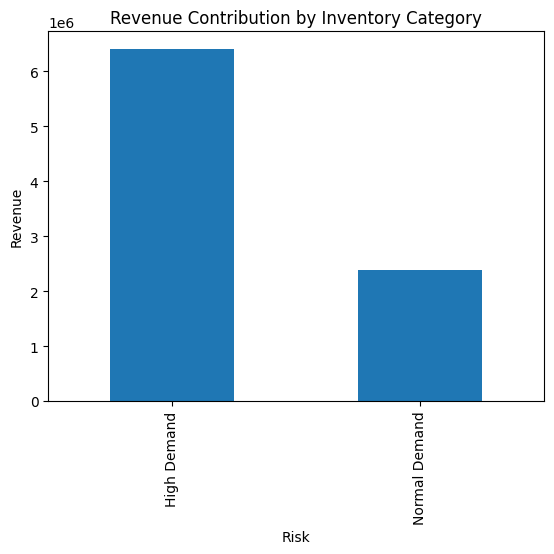

In [10]:
# Revenue contribution by risk
inventory.groupby("Risk")["Revenue"]\
         .sum()\
         .plot(kind="bar")

plt.title("Revenue Contribution by Inventory Category")
plt.ylabel("Revenue")

plt.show()

# Revenue Impact Insights

1. High-demand products contribute a significant portion of overall revenue.
2. Effective inventory planning for these products can improve business performance.
3. Revenue concentration highlights the importance of demand forecasting.
4. Inventory optimization can reduce lost sales caused by stock shortages.

In [11]:
high_demand_threshold

np.float64(1112.75)

# Inventory Optimization Insights

1. Products with demand above 1,112 units are classified as High Demand items.

2. 1,111 products fall into the High Demand category and require close inventory monitoring.

3. High Demand products should receive priority in replenishment planning.

4. 3,333 products are categorized as Normal Demand and can follow standard inventory policies.

5. Inventory classification helps reduce stock-out risk and improve product availability.

6. Demand-based inventory management can improve operational efficiency and customer satisfaction.

In [12]:
inventory.to_csv(
    "../data/inventory_analysis.csv",
    index=False
)